
### Generating and Plotting Betatron Oscillations

The goal of this code is to simulate the Betatron oscillations described by an electron circulating in Sirius, as a function of the *azimuth coordinate* $s$, for multiple turns.

More specifically, we will strive to reproduce Figure 2.6 of the *Sands textbook*, representing not only the electron trajectories, but also the 'betatron function' $\beta(s)$ and the envelope $X(s) = a\sqrt{(\beta(s))}$

Imports

In [311]:
import numpy as np
import matplotlib.pyplot as plt
import pymodels
import pyaccel

#### Model creation

In [312]:
model = pymodels.si.create_accelerator()
model.cavity_on = False
model.radiation_on = False
model.vchamber_on = False

In [313]:
print(model)

energy         : 3000000000.0 eV
harmonic_number: 864
cavity_on      : False
radiation_on   : 0
vchamber_on    : False
lattice version: SI_V25_04_1.21.3
lattice size   : 6752
lattice length : 518.3898999999917 m


#### Extracting parameters

Twiss

In [314]:
twiss, *_ = pyaccel.optics.calc_twiss(model)

print('Twiss array:\n')
print('type:', type(twiss), '\nshape:', np.shape(twiss), '\n') # TwissArray w/ < lattice_size > elements
print('1st element:\n\n', twiss[0], '\n', sep='')
print(type(twiss[0]))

Twiss array:

type: <class 'pyaccel.optics.twiss.TwissArray'> 
shape: (6752,) 

1st element:

spos          : +0.000e+00
rx, ry        : +0.000e+00, +0.000e+00
px, py        : +0.000e+00, +0.000e+00
de, dl        : +0.000e+00, +0.000e+00
mux, muy      : +0.000e+00, +0.000e+00
betax, betay  : +1.720e+01, +3.604e+00
alphax, alphay: -1.789e-13, +4.519e-14
etax, etapx   : +4.927e-08, +7.077e-16
etay, etapy   : +0.000e+00, +0.000e+00

<class 'pyaccel.optics.twiss.Twiss'>


spos; beta_x; beta_y

In [315]:
spos = twiss.spos
beta_x = twiss.betax
beta_y = twiss.betay

print(np.shape(spos), np.shape(beta_x), np.shape(beta_y))

(6752,) (6752,) (6752,)


In [316]:
idx = range(0, 120, 10)
print('spos:\n', spos[idx], '\n\nbeta_x:\n', beta_x[idx], '\n\nbeta_y:\n', beta_y[idx])

spos:
 [0.        2.5748475 4.2347475 5.0167475 5.4467475 5.5187475 5.8906075
 6.5407475 8.0707475 8.5312475 8.9562475 9.1762475] 

beta_x:
 [17.2013798  17.58680467 13.88877507  2.52811873  0.47558268  0.33921808
  0.43558214  3.84448009  7.66961024  3.07504414  0.89977833  0.44039862] 

beta_y:
 [ 3.60430347  5.44372673 10.93008619 24.94426761 28.90042684 28.81518193
 24.91188462 14.04268058 11.60488289 20.04729413 26.73779782 27.59604807]


#### Tracking trajectories

In [317]:
# Particle 1:
x1_0 = 0
px1_0 = 1e-7
y1_0 = 0
py1_0 = 1e-7

# Particle 2:
x2_0 = 2e-6
px2_0 = 0
y2_0 = 1e-6
py2_0 = 0

coord_inits = np.transpose(np.array([[x1_0, px1_0, y1_0, py1_0, 0, 0], [x2_0, px2_0, y2_0, py2_0, 0, 0]]))
print('Initial coordinates:\n\n', coord_inits, 'm', '\n\nshape:', np.shape(coord_inits))

Initial coordinates:

 [[0.e+00 2.e-06]
 [1.e-07 0.e+00]
 [0.e+00 1.e-06]
 [1.e-07 0.e+00]
 [0.e+00 0.e+00]
 [0.e+00 0.e+00]] m 

shape: (6, 2)


In [318]:
coord_fins, *_ = pyaccel.tracking.line_pass(model, coord_inits, indices='open') 

print(np.shape(coord_fins))
# -> (6, 2, 6752) -> (6, n_particles, n_elements)

print('\nIntermediate coordinates:\n')
print('Particle 1:', coord_fins[:, 0, int(coord_fins.shape[2]/2)], 'm')
print('Particle 2:', coord_fins[:, 1, int(coord_fins.shape[2]/2)], 'm')

print('\nFinal coordinates:\n')
print('Particle 1:', coord_fins[:, 0, -1], 'm\nParticle 2:', coord_fins[:, 1, -1], 'm')

(6, 2, 6752)

Intermediate coordinates:

Particle 1: [-1.14944814e-06 -3.23422046e-07  5.39173096e-07  1.40821845e-07
  0.00000000e+00 -5.91070855e-13] m
Particle 2: [-2.02767790e-07  1.16944665e-07 -6.27194660e-08 -2.01866097e-07
  0.00000000e+00 -1.98132482e-12] m

Final coordinates:

Particle 1: [ 9.75462926e-07  8.23683418e-08  2.93942318e-07  5.78747470e-08
  0.00000000e+00 -3.42565915e-12] m
Particle 2: [ 1.64739185e-06 -6.59481731e-08  5.78685227e-07 -2.26326281e-07
  0.00000000e+00 -1.93755708e-12] m


#### Plots

##### Fig. (a)

In [319]:
# Getting original parameters
spos = twiss.spos
beta_x = twiss.betax
beta_y = twiss.betay

In [320]:
# Limiting to 1/5 of the ring for better visualization:
spos = spos[:int(len(spos)/5)]
beta_x = beta_x[:int(len(beta_x)/5)]
beta_y = beta_y[:int(len(beta_y)/5)]

Plotting betatron functions ($\beta_x$ and $\beta_y$) along the ring:

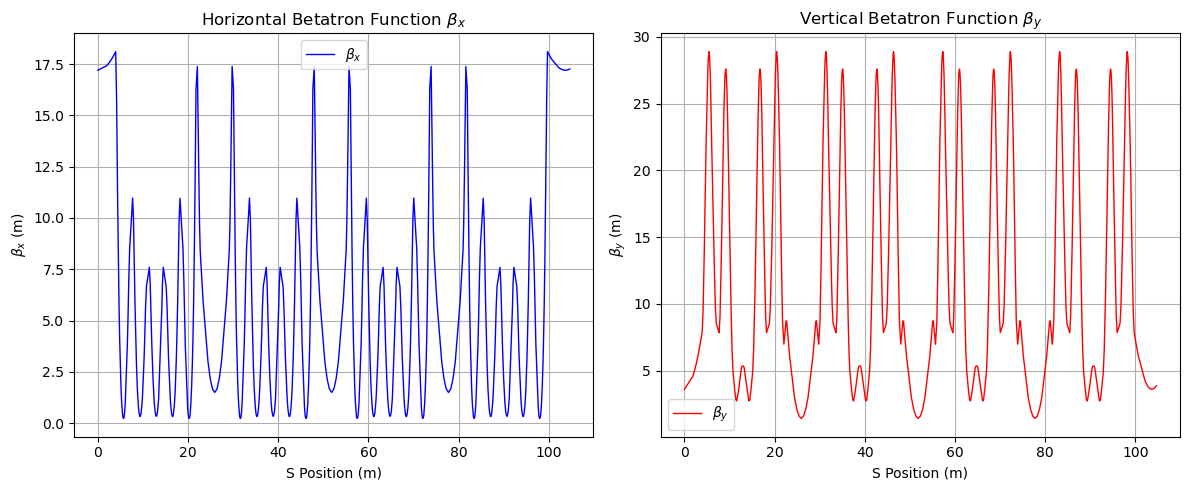

In [321]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(spos, beta_x, label=r'$\beta_x$', color='blue', linewidth=1)
plt.xlabel('s [m]')
plt.ylabel(r'$\beta_x$ [m]')
plt.title(r'Horizontal Betatron Function $\beta_x$')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(spos, beta_y, label=r'$\beta_y$', color='red', linewidth=1)
plt.xlabel('s [m]')
plt.ylabel(r'$\beta_y$ [m]')
plt.title(r'Vertical Betatron Function $\beta_y$')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

##### Fig. (b)

First, calculating the trajectories' envelopes $a\sqrt{\beta(s)}$:

To determine the constant $a$ (*which depends on the initial conditions of the particular trajectory*), we use:

\begin{equation}
    a^2 = \frac{x^2_1}{\beta_1} + \beta_1\left[x'_1 - \frac{\beta'_1}{2\beta_1}x_1\right]²,
\end{equation}

where $(x_1, x'_1, \beta_1, \beta'_1)$ $\triangleq$ $\left(x(s_1), x'(s_1), \beta(s_1), \beta'(s_1)\right)$, for a given $s_1$ where $(x,$ $x')$ are known.

Moreover, $\beta'(s)$ can be obtained as:

\begin{equation}
    \beta'(s) = -2\alpha(s),
\end{equation}
and thus:

\begin{equation}
    a = \left[\frac{x^2_1}{\beta_1} + \beta_1\left(x'_1 + \frac{\alpha_1}{\beta_1}x_1\right)²\right]^{\frac{1}{2}}.
\end{equation}

Particle 1

In [383]:
def calc_a(x1, xprime1, betax1, alphax1):
    return np.sqrt(x1**2/betax1 + betax1*(xprime1 + alphax1/betax1*x1)**2)

# x motion:
alpha_x = twiss.alphax

# constant 'a' using initial coordinates:

a_x1 = x1_0
a_xprime1 = px1_0
a_betax1 = beta_x[0] # beta at the start of the ring
a_alphax1 = alpha_x[0] # alpha at the start of the ring

# a = [x_1^2/\beta_1 + \beta_1*(x'_1 + (\alpha_1/\beta_1)*x_1 )^2]^(1/2):

a_x_par1 = calc_a(a_x1, a_xprime1, a_betax1, a_alphax1)

# envelope function (a\sqrt{\beta}):
envelope_x1 = a_x_par1 * np.sqrt(beta_x)

# ---  ---

# y motion:
alpha_y = twiss.alphay

# At the start of the ring:
a_y1 = y1_0
a_yp1 = py1_0
a_betay1 = beta_y[0]
a_alphay1 = alpha_y[0]
a_y_par1 = calc_a(a_y1, a_yp1, a_betay1, a_alphay1)

# envelope:
envelope_y1 = a_y_par1 * np.sqrt(beta_y)


Particle 2

In [384]:
# x motion:
a_x2 = x2_0
a_xprime2 = px2_0
a_betax2 = beta_x[0]
a_alphax2 = alpha_x[0]
a_x_par2 = calc_a(a_x2, a_xprime2, a_betax2, a_alphax2)
envelope_x2 = a_x_par2 * np.sqrt(beta_x)

# y motion:
a_y2 = y2_0
a_yp2 = py2_0
a_betay2 = beta_y[0]
a_alphay2 = alpha_y[0]
a_y_par2 = calc_a(a_y2, a_yp2, a_betay2, a_alphay2)
envelope_y2 = a_y_par2 * np.sqrt(beta_y)

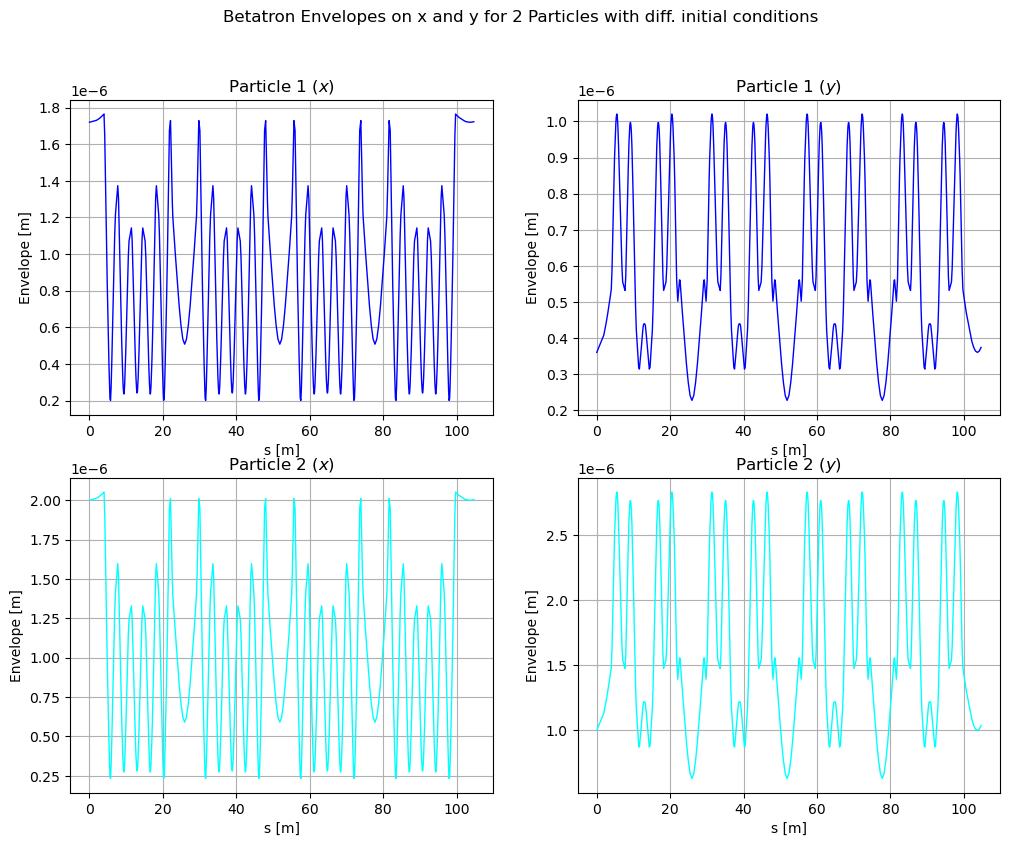

In [ ]:
# plotting all envelopes:
plt.figure(figsize=(12, 9))

# particle 1:
plt.subplot(2, 2, 1) # x
plt.plot(spos, envelope_x1, color='blue', linewidth=1)
plt.xlabel('s [m]')
plt.ylabel('Envelope [m]')
plt.title('Particle 1 ($x$)')
plt.grid(True)

plt.subplot(2, 2, 2) # y
plt.plot(spos, envelope_y1, color='blue', linewidth=1)
plt.xlabel('s [m]')
plt.ylabel('Envelope [m]')
plt.title('Particle 1 ($y$)')
plt.grid(True)

# particle 2:
plt.subplot(2, 2, 3) # x
plt.plot(spos, envelope_x2, color='cyan', linewidth=1)
plt.xlabel('s [m]')
plt.ylabel('Envelope [m]')
plt.title('Particle 2 ($x$)')
plt.grid(True)

plt.subplot(2, 2, 4) # y
plt.plot(spos, envelope_y2, color='cyan', linewidth=1)
plt.xlabel('s [m]')
plt.ylabel('Envelope [m]')
plt.title('Particle 2 ($y$)')
plt.grid(True)

plt.suptitle('Betatron Envelopes on x and y for 2 Particles with diff. initial conditions')

plt.show()

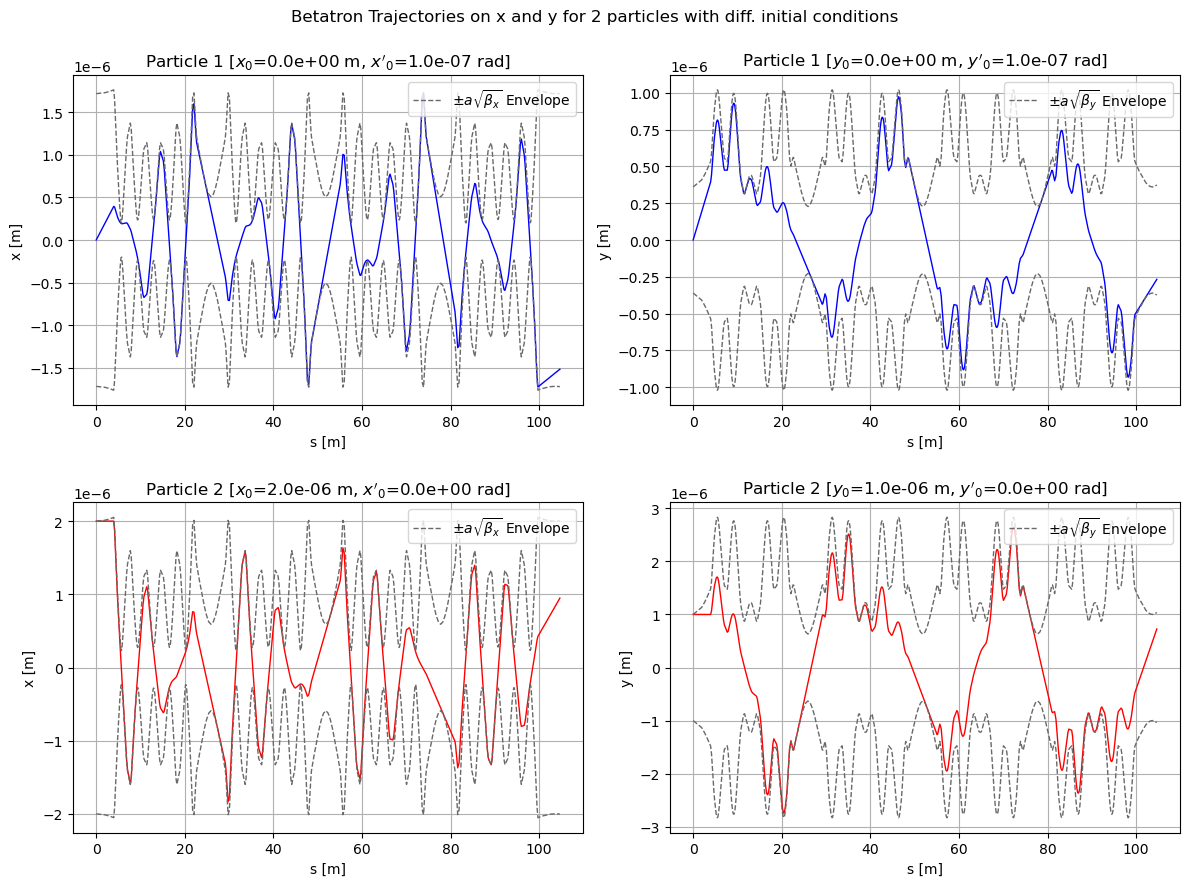

In [403]:
# plotting all trajectories:
plt.figure(figsize=(12, 9))

# Particle 1:
plt.subplot(2, 2, 1) # x
plt.plot(spos, coord_fins[0, 0, :len(spos)], color='blue', linewidth=1)
plt.plot(spos, envelope_x1, label=r'$\pm a\sqrt{\beta_x}$ Envelope', color='dimgrey', linestyle='--', linewidth=1)
plt.plot(spos, -envelope_x1, color='dimgrey', linestyle='--', linewidth=1)
plt.xlabel('s [m]')
plt.ylabel('x [m]')
plt.title(f'Particle 1 [$x_0$={x1_0:.1e} m, $x\'_0$={px1_0:.1e} rad]')
plt.grid(True)
plt.legend(loc='upper right')

plt.subplot(2, 2, 2) # y
plt.plot(spos, coord_fins[2, 0, :len(spos)], color='blue', linewidth=1)
plt.plot(spos, envelope_y1, label=r'$\pm a\sqrt{\beta_y}$ Envelope', color='dimgrey', linestyle='--', linewidth=1)
plt.plot(spos, -envelope_y1, color='dimgrey', linestyle='--', linewidth=1)
plt.xlabel('s [m]')
plt.ylabel('y [m]')
plt.title(f'Particle 1 [$y_0$={y1_0:.1e} m, $y\'_0$={py1_0:.1e} rad]')
plt.grid(True)
plt.legend(loc='upper right')

# Particle 2:
plt.subplot(2, 2, 3) # x
plt.plot(spos, coord_fins[0, 1, :len(spos)], color='red', linewidth=1)
plt.plot(spos, envelope_x2, label=r'$\pm a\sqrt{\beta_x}$ Envelope', color='dimgrey', linestyle='--', linewidth=1)
plt.plot(spos, -envelope_x2, color='dimgrey', linestyle='--', linewidth=1)
plt.xlabel('s [m]')
plt.ylabel('x [m]')
plt.title(f'Particle 2 [$x_0$={x2_0:.1e} m, $x\'_0$={px2_0:.1e} rad]')
plt.grid(True)
plt.legend(loc='upper right')

plt.subplot(2, 2, 4) # y
plt.plot(spos, coord_fins[2, 1, :len(spos)], color='red', linewidth=1)
plt.plot(spos, envelope_y2, label=r'$\pm a\sqrt{\beta_y}$ Envelope', color='dimgrey', linestyle='--', linewidth=1)
plt.plot(spos, -envelope_y2, color='dimgrey', linestyle='--', linewidth=1)
plt.xlabel('s [m]')
plt.ylabel('y [m]')
plt.title(f'Particle 2 [$y_0$={y2_0:.1e} m, $y\'_0$={py2_0:.1e} rad]')
plt.grid(True)
plt.legend(loc='upper right')

plt.suptitle('Betatron Trajectories on x and y for 2 particles with diff. initial conditions')

plt.tight_layout()
plt.show()

Particle 1's trajectory on the horizontal and vertical planes (*with arrows*)

In [406]:
def add_arrows(ax, line, n_arrows=5):
    xdata = line.get_xdata()
    ydata = line.get_ydata()
    
    step = len(xdata) // (n_arrows + 1)
    
    for i in range(step, len(xdata)-step, step):
        ax.annotate(
            '',
            xy=(xdata[i+1], ydata[i+1]),
            xytext=(xdata[i], ydata[i]),
            arrowprops=dict(
                arrowstyle='-|>',
                color=line.get_color(),
                lw=2.5
            ),
        )

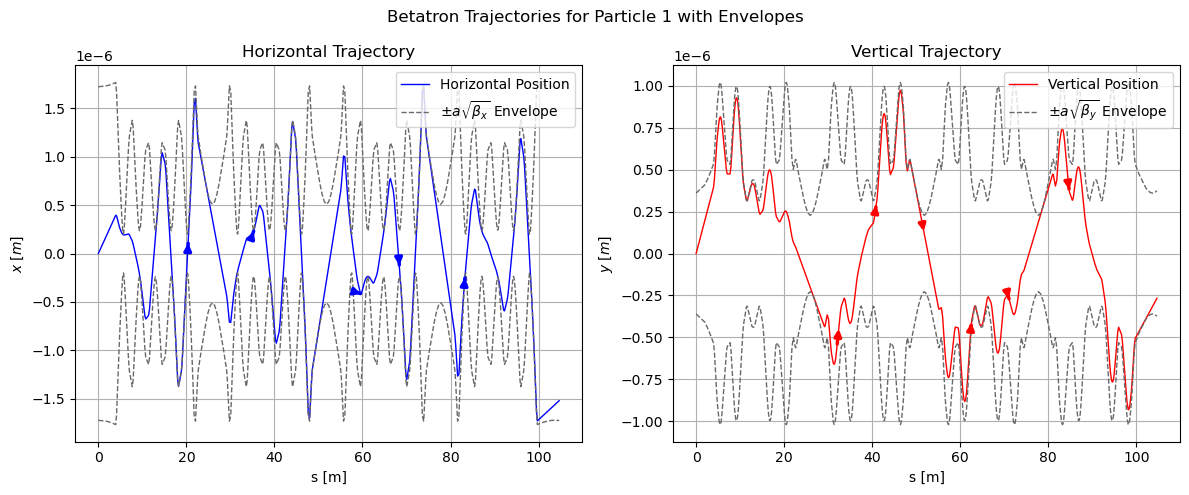

In [418]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -------- Horizontal --------
ax = axes[0]

line_h = ax.plot(
    spos,
    coord_fins[0, 0, :len(spos)],
    label='Horizontal Position',
    color='blue',
    linewidth=1
)[0]

add_arrows(ax, line_h, n_arrows=8)

ax.plot(spos, envelope_x1, '--', label=r'$\pm a\sqrt{\beta_x}$ Envelope', color='dimgrey', linewidth=1)
ax.plot(spos, -envelope_x1, '--', color='dimgrey', linewidth=1)

ax.set_xlabel('s [m]')
ax.set_ylabel(r'$x$ [$m$]')
ax.set_title('Horizontal Trajectory')
ax.grid(True)
ax.legend(loc='upper right')

# -------- Vertical --------
ax = axes[1]

line_v = ax.plot(
    spos,
    coord_fins[2, 0, :len(spos)],
    label='Vertical Position',
    color='red',
    linewidth=1
)[0]

add_arrows(ax, line_v, n_arrows=9)

ax.plot(spos, envelope_y1, '--', color='dimgrey', label=r'$\pm a\sqrt{\beta_y}$ Envelope', linewidth=1)
ax.plot(spos, -envelope_y1, '--', color='dimgrey', linewidth=1)

ax.set_xlabel('s [m]')
ax.set_ylabel(r'$y$ [$m$]')
ax.set_title('Vertical Trajectory')
ax.grid(True)
ax.legend(loc='upper right')

plt.suptitle('Betatron Trajectories for Particle 1 with Envelopes')

plt.tight_layout()
plt.show()

Same for particle 2

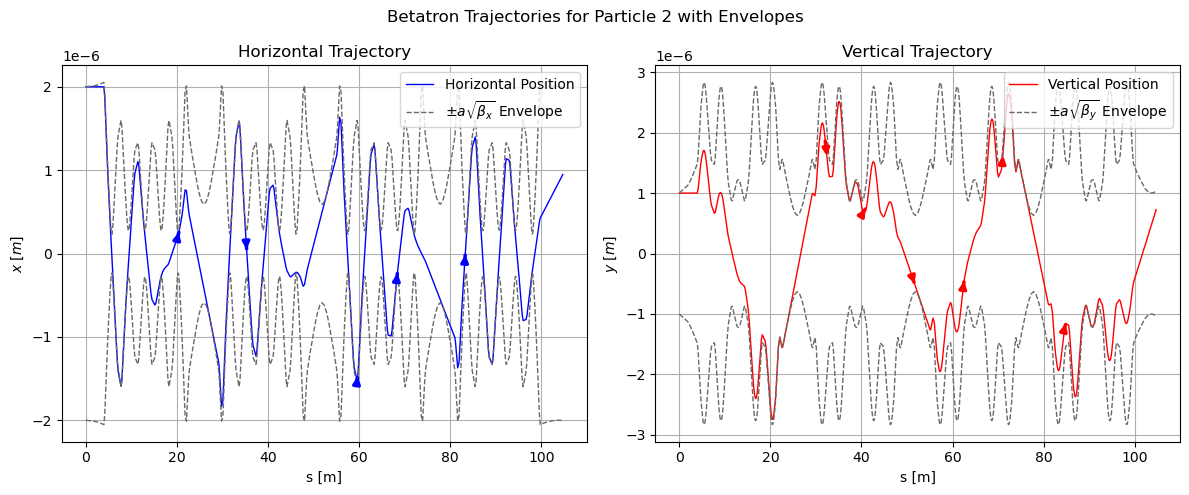

In [419]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -------- Horizontal --------
ax = axes[0]

line_h = ax.plot(
    spos,
    coord_fins[0, 1, :len(spos)],
    label='Horizontal Position',
    color='blue',
    linewidth=1
)[0]

add_arrows(ax, line_h, n_arrows=8)

ax.plot(spos, envelope_x2, '--', label=r'$\pm a\sqrt{\beta_x}$ Envelope', color='dimgrey', linewidth=1)
ax.plot(spos, -envelope_x2, '--', color='dimgrey', linewidth=1)

ax.set_xlabel('s [m]')
ax.set_ylabel(r'$x$ [$m$]')
ax.set_title('Horizontal Trajectory')
ax.grid(True)
ax.legend(loc='upper right')

# -------- Vertical --------
ax = axes[1]

line_v = ax.plot(
    spos,
    coord_fins[2, 1, :len(spos)],
    label='Vertical Position',
    color='red',
    linewidth=1
)[0]

add_arrows(ax, line_v, n_arrows=9)

ax.plot(spos, envelope_y2, '--', color='dimgrey', label=r'$\pm a\sqrt{\beta_y}$ Envelope', linewidth=1)
ax.plot(spos, -envelope_y2, '--', color='dimgrey', linewidth=1)

ax.set_xlabel('s [m]')
ax.set_ylabel(r'$y$ [$m$]')
ax.set_title('Vertical Trajectory')
ax.grid(True)
ax.legend(loc='upper right')

plt.suptitle('Betatron Trajectories for Particle 2 with Envelopes')

plt.tight_layout()
plt.show()

##### Fig. (d)

-> Tracking multiple turns

In [437]:

coord_ini0 = np.array([x1_0, px1_0, y1_0, py1_0, 0, 0])
coord_fin0, *_ = pyaccel.tracking.line_pass(model, coord_ini0, indices='closed') 

print(np.shape(coord_fin0))
# -> (6, 6752) -> (6, lattice_size+1)

coord_ini1 = coord_fin0[:, -1] # Getting the final coordinates after 1 turn
coord_fin1, *_ = pyaccel.tracking.line_pass(model, coord_ini1, indices='closed')

coord_ini2 = coord_fin1[:, -1] # Getting the final coordinates after 2 turns
coord_fin2, *_ = pyaccel.tracking.line_pass(model, coord_ini2, indices='closed')

coor_ini3 = coord_fin2[:, -1] # Getting the final coordinates after 3 turns
coord_fin3, *_ = pyaccel.tracking.line_pass(model, coor_ini3, indices='closed')

coor_ini4 = coord_fin3[:, -1] # Getting the final coordinates after 4 turns
coord_fin4, *_ = pyaccel.tracking.line_pass(model, coor_ini4, indices='closed')


(6, 6753)


Plotting tracjectories for multiple turns

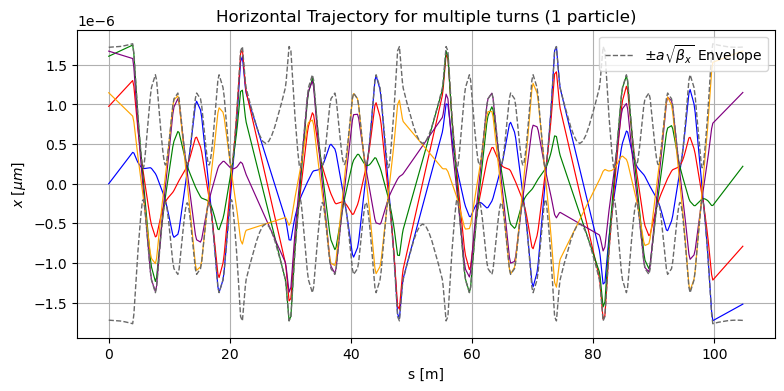

In [438]:
plt.figure(figsize=(9, 4))

plt.plot(spos, coord_fin0[0, :len(spos)], color='blue', linewidth=0.85)
plt.plot(spos, coord_fin1[0, :len(spos)], color='red', linewidth=0.85)
plt.plot(spos, coord_fin2[0, :len(spos)], color='green', linewidth=0.85)
plt.plot(spos, coord_fin3[0, :len(spos)], color='purple', linewidth=0.85)
plt.plot(spos, coord_fin4[0, :len(spos)], color='orange', linewidth=0.85)
# Adding envelopes sqrt(beta) to the plots for better visualization of the trajectories:
plt.plot(spos, envelope_x1, label=r'$\pm a\sqrt{\beta_x}$ Envelope', color='dimgrey', linestyle='--', linewidth=1)
plt.plot(spos, -envelope_x1, color='dimgrey', linestyle='--', linewidth=1)
plt.xlabel('s [m]')
plt.ylabel(r'$x$ [$\mu m$]')
plt.title(r'Horizontal Trajectory for multiple turns (1 particle)')
plt.grid(True)
plt.legend(loc='upper right')

plt.show()

With arrows to indicate the trajectories

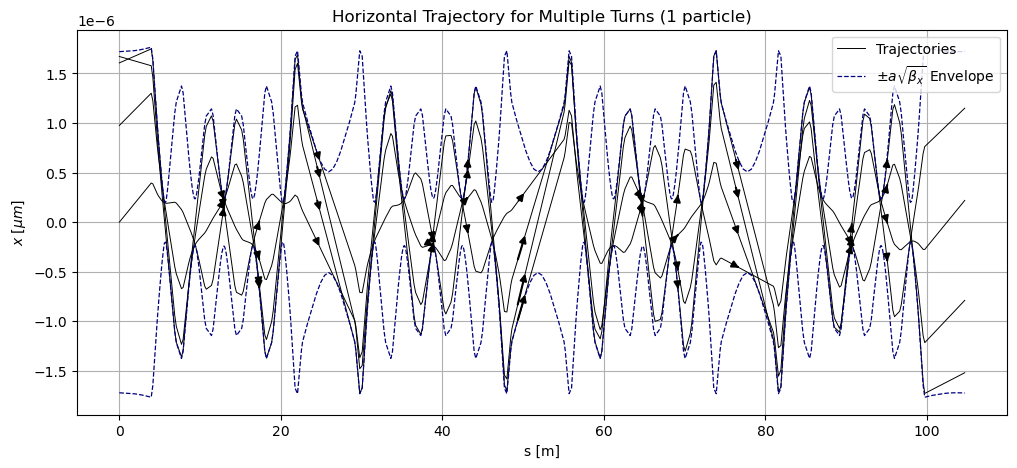

In [439]:
fig, ax = plt.subplots(figsize=(12, 5))

lines = []
lines.append(ax.plot(spos, coord_fin0[0, :len(spos)], color='black', linewidth=0.7, label='Trajectories')[0])
lines.append(ax.plot(spos, coord_fin1[0, :len(spos)], color='black', linewidth=0.7)[0])
lines.append(ax.plot(spos, coord_fin2[0, :len(spos)], color='black', linewidth=0.7)[0])
lines.append(ax.plot(spos, coord_fin3[0, :len(spos)], color='black', linewidth=0.7)[0])

# Function to add arrows along a line
def add_arrows(line, n_arrows=5):
    xdata = line.get_xdata()
    ydata = line.get_ydata()
    
    step = len(xdata) // (n_arrows + 1)
    
    for i in range(step, len(xdata)-step, step):
        ax.annotate(
            '',
            xy=(xdata[i+1], ydata[i+1]),
            xytext=(xdata[i], ydata[i]),
            arrowprops=dict(arrowstyle='-|>', color=line.get_color(), lw=1.5),
        )

# Add arrows to each trajectory
for line in lines:
    add_arrows(line, n_arrows=15)

# Envelopes
ax.plot(spos, envelope_x1, '--', color='navy', linewidth=0.9, label=r'$\pm a\sqrt{\beta_x}$ Envelope')
ax.plot(spos, -envelope_x1, '--', color='navy', linewidth=0.9)

ax.set_xlabel('s [m]')
ax.set_ylabel(r'$x$ [$\mu m$]')
ax.set_title('Horizontal Trajectory for Multiple Turns (1 particle)')
plt.legend()
ax.grid(True)

plt.show()